In [5]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio


### Q1

Implement a 2D convolution in `numpy`. Here is a [tutorial](https://github.com/detkov/Convolution-From-Scratch).

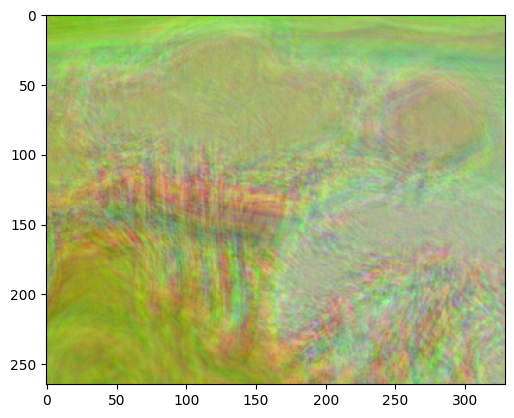

In [30]:
def conv_2d(img, kernel, kind='valid'):
    num_rows = img.shape[0] - kernel.shape[0] + 1
    num_cols = img.shape[1] - kernel.shape[1] + 1
    out = np.zeros((num_rows, num_cols, img.shape[2]))
    for row in range(num_rows):
        for col in range(num_cols):
            out[row, col] = np.sum(np.expand_dims(img[
                    row:row+kernel.shape[0], col:col+kernel.shape[1]
            ], axis=-1) * kernel, axis=(0, 1, 2))
    return out

img_path = "../files/trees.png"
img = imageio.imread(img_path)[:, :, :3]
kernel = np.random.normal(0, 1, size=(32, 32, img.shape[2], img.shape[2]))
img = conv_2d(img, kernel)
img -= np.amin(img)
img /= np.amax(img)

plt.imshow(img)
plt.show()


### Question 12

**Q.** You have two urns, five red balls, and five blue balls. You can distribute the balls into the urns any way you like, but each urn must have at least one ball in it. I will choose one urn at random (p = 0.5) and then draw one ball from it. If the ball is blue, you win. How should you distribute the balls to maximise your probability of winning? Log into this pair-programming website and
use Python or C++ to solve the problem while I watch.

**A.** I want to maximise the probability of winning in terms of the urn assigned to each ball, which is 
$$P = p \frac{n_b}{n_b + n_r} + (1 - p) \frac{5 - n_b}{10 - n_b - n_r} = \frac{(10 - n_b - n_r) n_b}{2 (n_b + n_r) (5 - n_b)}$$
$$P = \frac{10b - b^2 - rb}{2(5b + 5r - b^2 - br)}$$

Also, $b, r \in \{1:4\}$.

In [ ]:
def p(r, b, t, p):